In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.models.ODEWrapper import ODEWrapper
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torchdiffeq import odeint 

from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
from gsnn.interpret.NoiseTunnel import NoiseTunnel
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.OcclusionExplainer import OcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance, plot_node_importance
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer
from gsnn.interpret.ContrastiveGSNNExplainer import ContrastiveGSNNExplainer

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import seaborn as sbn
import gseapy as gp

%load_ext autoreload
%autoreload 2


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
  warnings.warn(msg)


Trametinib (MEK inhibitor) – MAPK-addicted vs MAPK-independent context: If trametinib (MEK1/2 inhibitor) causes significant suppression of ERK-dependent genes – for example, downregulating the feedback regulator DUSP6 – in RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20), which have hyperactive MAPK signaling and are very sensitive to MEK inhibition, but produces little change in those same genes in PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition), due to the latter’s proliferation being driven by alternate pathways (e.g. PI3K/ER signaling rather than MAPK), then MyModel should predict that DUSP6 (and other ERK-target genes) drop in MDA-MB-231/BT-20 but remain relatively unchanged in MCF7/T47D. The model’s contrastive explanation should implicate the RAS–RAF–MEK–ERK cascade as the differentiating factor – for instance, highlighting mutant KRAS/BRAF or downstream ERK activity as the mediator for gene suppression in the RAS-driven cells (In essence, the explanation would show that trametinib’s effect on gene expression is contingent on MAPK pathway addiction, consistent with literature reports that trametinib downregulates ERK-feedback genes like DUSP6 in KRAS-driven cancers).

In [2]:
root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included'
#root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included_02'
#root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_no_mirna_01'

cres = pd.read_csv(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_cres.csv')
out_dict = torch.load(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_out_dict.pt')

/tmp/ipykernel_383/3097589615.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  out_dict = torch.load(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_out_dict.

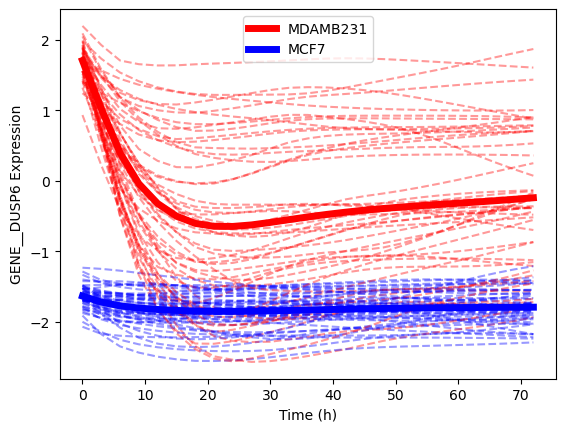

In [3]:

gsnn_trajs_x1 = [] 
gsnn_trajs_x2 = [] 
for sample_id, sample_dict in out_dict.items():

    gsnn_trajs_x1.append(sample_dict['xt_hat_1'][:, sample_dict['target_gene_output_ix']])
    gsnn_trajs_x2.append(sample_dict['xt_hat_2'][:, sample_dict['target_gene_output_ix']])

gsnn_trajs_x1 = np.stack(gsnn_trajs_x1, axis=0) 
gsnn_trajs_x2 = np.stack(gsnn_trajs_x2, axis=0) 

plt.figure() 
for i in range(gsnn_trajs_x1.shape[0]):
    plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x1[i], 'r--', alpha=0.4)
    plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x2[i], 'b--', alpha=0.4)

plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x1.mean(axis=0), 'r-', linewidth=5, label=out_dict['sample_0']['cell_line_1']) # make dark red 
plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x2.mean(axis=0), 'b-', linewidth=5, label=out_dict['sample_0']['cell_line_2'])

plt.xlabel('Time (h)')
plt.ylabel(f'{out_dict["sample_0"]["target_gene"]} Expression')
plt.legend()
plt.show()




In [4]:
#cres = cres.fillna(0) 
cres_gsnn = cres[['source', 'target'] + [f'gsnn_score_sample_{i}' for i in range(50)]].fillna(0)
cres_gsnn = cres_gsnn.set_index(['source', 'target'])
cres_gsnn = cres_gsnn.assign(mean_gsnn_score = cres_gsnn.values.mean(axis=1))
cres_gsnn = cres_gsnn.assign(std_gsnn_score = cres_gsnn.values.std(axis=1))
cres_gsnn = cres_gsnn.assign(prob_gsnn_score = (cres_gsnn.values > 0.5).mean(axis=1))
cres_gsnn = cres_gsnn[['mean_gsnn_score', 'std_gsnn_score', 'prob_gsnn_score']]

cres_ig = cres[['source', 'target'] + [f'ig_score_sample_{i}' for i in range(50)]].fillna(0)
cres_ig = cres_ig.set_index(['source', 'target'])
cres_ig = cres_ig.assign(mean_ig_score = cres_ig.values.mean(axis=1))
cres_ig = cres_ig.assign(std_ig_score = cres_ig.values.std(axis=1))
cres_ig = cres_ig.assign(prob_pos_ig_score = (cres_ig.values > 0.).mean(axis=1))
cres_ig = cres_ig.assign(prob_neg_ig_score = (cres_ig.values < 0.).mean(axis=1))
cres_ig = cres_ig[['mean_ig_score', 'std_ig_score', 'prob_pos_ig_score', 'prob_neg_ig_score']]

cres_oc = cres[['source', 'target'] + [f'occlusion_score_sample_{i}' for i in range(50)]].fillna(0)
cres_oc = cres_oc.set_index(['source', 'target'])
cres_oc = cres_oc.assign(mean_oc_score = cres_oc.values.mean(axis=1))
cres_oc = cres_oc.assign(std_oc_score = cres_oc.values.std(axis=1))
cres_oc = cres_oc.assign(prob_pos_oc_score = (cres_oc.values > 0.).mean(axis=1))
cres_oc = cres_oc.assign(prob_neg_oc_score = (cres_oc.values < 0.).mean(axis=1))    
cres_oc = cres_oc[['mean_oc_score', 'std_oc_score', 'prob_pos_oc_score', 'prob_neg_oc_score']]

cres_agg = cres_gsnn.merge(cres_ig, on=['source', 'target'], how='inner').merge(cres_oc, on=['source', 'target'], how='inner')
cres_agg = cres_agg.assign(abs_ig_score = lambda x: x.mean_ig_score.abs(),
                           abs_oc_score = lambda x: x.mean_oc_score.abs())

cres_agg.sort_values(by='abs_ig_score', ascending=False).head(100)


mean_gsnn_score  std_gsnn_score  \
source               target                                             
RNA__DUSP6           GENE__DUSP6             0.999952        0.000085   
DRUG__BRD-K12343256  PROTEIN__MAP2K1         0.998185        0.006857   
PROTEIN__FOXO3       RNA__DUSP6              0.980101        0.132964   
RNA__hsa-miR-181a-5p RNA__DUSP6              0.999482        0.001286   
LINE__MDAMB231       RNA__DUSP6              0.999851        0.000445   
...                                               ...             ...   
                     RNA__KEAP1              0.629781        0.444145   
                     PROTEIN__FOXO3          0.990076        0.040249   
                     RNA__FYN                0.557285        0.467895   
                     RNA__LYN                0.716437        0.410050   
GENE__KEAP1          RNA__KEAP1              0.686885        0.439824   

                                      prob_gsnn_score  mean_ig_score  \
source               target                                            
RNA__DUSP6           GENE__DUSP6             0.980769       0.838411   
DRUG__BRD-K12343256  PROTEIN__MAP2K1         0.980769       0.320484   
PROTEIN__FOXO3       RNA__DUSP6              0.961538       0.202804   
RNA__hsa-miR-181a-5p RNA__DUSP6              0.980769       0.193087   
LINE__MDAMB231       RNA__DUSP6              0.980769      -0.156222   
...                                               ...            ...   
                     RNA__KEAP1              0.615385      -0.009383   
                     PROTEIN__FOXO3          0.980769      -0.009273   
                     RNA__FYN                0.538462       0.009103   
                     RNA__LYN                0.673077      -0.009098   
GENE__KEAP1          RNA__KEAP1              0.673077       0.008763   

                                      std_ig_score  prob_pos_ig_score  \
source               target                                             
RNA__DUSP6           GENE__DUSP6          0.394751           1.000000   
DRUG__BRD-K12343256  PROTEIN__MAP2K1      0.216513           1.000000   
PROTEIN__FOXO3       RNA__DUSP6           0.140472           0.942308   
RNA__hsa-miR-181a-5p RNA__DUSP6           0.141928           0.942308   
LINE__MDAMB231       RNA__DUSP6           0.263906           0.250000   
...                                            ...                ...   
                     RNA__KEAP1           0.026848           0.211538   
                     PROTEIN__FOXO3       0.030890           0.442308   
                     RNA__FYN             0.037654           0.365385   
                     RNA__LYN             0.042510           0.346154   
GENE__KEAP1          RNA__KEAP1           0.028840           0.480769   

                                      prob_neg_ig_score  mean_oc_score  \
source               target                                              
RNA__DUSP6           GENE__DUSP6               0.000000       2.337352   
DRUG__BRD-K12343256  PROTEIN__MAP2K1           0.000000       1.556895   
PROTEIN__FOXO3       RNA__DUSP6                0.037736       0.762912   
RNA__hsa-miR-181a-5p RNA__DUSP6                0.056604       0.751513   
LINE__MDAMB231       RNA__DUSP6                0.735849      -0.178317   
...                                                 ...            ...   
                     RNA__KEAP1                0.415094      -0.008759   
                     PROTEIN__FOXO3            0.547170      -0.006851   
                     RNA__FYN                  0.188679       0.006914   
                     RNA__LYN                  0.339623      -0.026513   
GENE__KEAP1          RNA__KEAP1                0.207547      -0.003047   

                                      std_oc_score  prob_pos_oc_score  \
source               target                                             
RNA__DUSP6           GENE__DUSP6          0.971299           1.000000   
DRUG__BRD-K12343256

In [17]:
#cres_agg.reset_index()[lambda x: x.source.str.contains('hsa-miR-342-3p') | x.target.str.contains('hsa-miR-342-3p')].sort_values(by='mean_gsnn_score', ascending=False)\
#    .sort_values(by='mean_gsnn_score', ascending=False).head(10)

# edges > 0.5 mean gsnn score 853
total # edges 43637


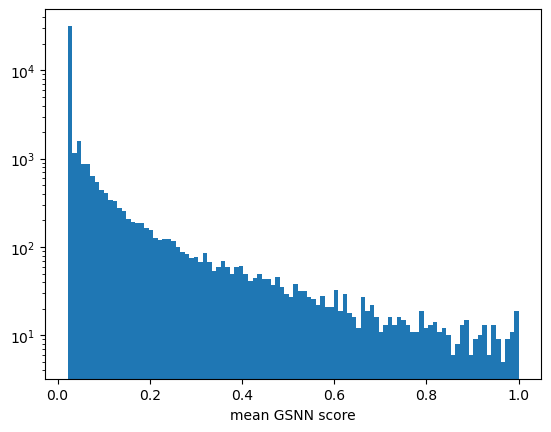

In [5]:
print('# edges > 0.5 mean gsnn score', len(cres_agg[cres_agg.mean_gsnn_score > 0.5]))
print('total # edges', len(cres_agg))

plt.figure()
plt.hist(cres_agg.mean_gsnn_score.values, bins=100)
plt.yscale('log')
plt.xlabel('mean GSNN score')
plt.show()

In [6]:
cres_agg.head()

mean_gsnn_score  std_gsnn_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.998185        0.006857   
                    PROTEIN__MAP2K2         0.989901        0.024313   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.025500        0.007484   
                    PROTEIN__ERBB2          0.025055        0.006997   
                    PROTEIN__ERBB4          0.026630        0.007858   

                                     prob_gsnn_score  mean_ig_score  \
source              target                                            
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.980769       0.320484   
                    PROTEIN__MAP2K2         0.980769       0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.000000       0.000000   
                    PROTEIN__ERBB2          0.000000       0.000000   
                    PROTEIN__ERBB4          0.000000       0.000000   

                                     std_ig_score  prob_pos_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.216513                1.0   
                    PROTEIN__MAP2K2      0.144622                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_ig_score  mean_oc_score  \
source              target                                              
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0       1.556895   
                    PROTEIN__MAP2K2                0.0       0.608180   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0       0.000000   
                    PROTEIN__ERBB2                 0.0       0.000000   
                    PROTEIN__ERBB4                 0.0       0.000000   

                                     std_oc_score  prob_pos_oc_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.713094                1.0   
                    PROTEIN__MAP2K2      0.508077                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_oc_score  abs_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0      0.320484   
                    PROTEIN__MAP2K2                0.0      0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0      0.000000   
                    PROTEIN__ERBB2                 0.0      0.000000   
                    PROTEIN__ERBB4                 0.0      0.000000   

                                     abs_oc_score  
source              target                         
DRUG__BRD-K12343256 PROTEIN__MAP2K1      1.556895  
                    PROTEIN__MAP2K2      0.608180  
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000  
                    PROTEIN__ERBB2       0.000000  
                    PROTEIN__ERBB4       0.000000

In [7]:
cres_agg.reset_index()[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))].sort_values(by='mean_gsnn_score', ascending=False).head(25)

,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
39200,RNA__DUSP6,GENE__DUSP6,0.999952,0.000085,0.980769,0.838411,0.394751,1.000000,0.000000,2.337352,0.971299,1.000000,0.000000,0.838411,2.337352
691,GENE__DUSP6,RNA__DUSP6,0.999935,0.000123,0.980769,-0.003997,0.249231,0.461538,0.528302,-0.002941,0.284918,0.519231,0.471698,0.003997,0.002941
41733,RNA__hsa-miR-181a-5p,RNA__DUSP6,0.999482,0.001286,0.980769,0.193087,0.141928,0.942308,0.056604,0.751513,0.463719,0.980769,0.018868,0.193087,0.751513
467,GENE__AKT1,RNA__AKT1,0.998993,0.003970,0.980769,0.023194,0.102895,0.596154,0.396226,0.048512,0.125812,0.634615,0.358491,0.023194,0.048512
1342,GENE__TP53,RNA__TP53,0.998890,0.003368,0.980769,0.028041,0.072709,0.730769,0.264151,0.047918,0.119482,0.750000,0.245283,0.028041,0.047918
0,DRUG__BRD-K12343256,PROTEIN__MAP2K1,0.998185,0.006857,0.980769,0.320484,0.216513,1.000000,0.000000,1.556895,0.713094,1.000000,0.000000,0.320484,1.556895
1273,GENE__STAT3,RNA__STAT3,0.996700,0.015629,0.980769,0.007870,0.088637,0.615385,0.377358,0.010209,0.304568,0.538462,0.452830,0.007870,0.010209
28041,PROTEIN__ETS1,RNA__DUSP6,0.996279,0.010293,0.980769,0.063263,0.077151,0.846154,0.150943,0.250903,0.267695,0.826923,0.169811,0.063263,0.250903
41140,RNA__hsa-miR-125b,RNA__DUSP6,0.993894,0.015532,0.980769,0.063155,0.068502,0.884615,0.113208,0.228206,0.258559,0.807692,0.188679,0.063155,0.228206
726,GENE__ETS1,RNA__ETS1,0.993014,0.028533,0.980769,0.010201,0.079427,0.576923,0.415094,0.031233,0.178532,0.576923,0.415094,0.010201,0.031233


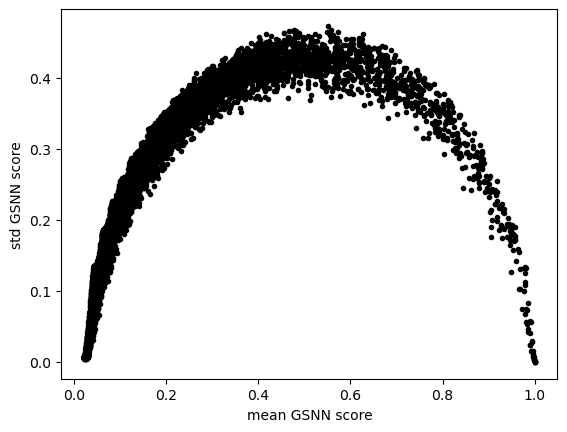

In [8]:
plt.figure()
plt.plot(cres_agg.mean_gsnn_score.values, cres_agg.std_gsnn_score.values, 'k.')
plt.xlabel('mean GSNN score')
plt.ylabel('std GSNN score')
plt.show()




In [9]:
cres_agg.reset_index()[lambda x: x.source.str.contains('RAS') | x.target.str.contains('RAS')].sort_values(by='mean_gsnn_score', ascending=False).head(10)

,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
14052,LINE__MDAMB231,PROTEIN__HRAS,0.122698,0.249063,0.096154,-0.000590,0.002777,0.038462,0.094340,-0.000567,0.002457,0.038462,0.094340,0.000590,0.000567
29951,PROTEIN__HRAS,PROTEIN__SHC1,0.075380,0.175026,0.038462,-0.000189,0.002180,0.038462,0.037736,-0.001149,0.009582,0.038462,0.037736,0.000189,0.001149
29948,PROTEIN__HRAS,PROTEIN__JUN,0.050451,0.088030,0.019231,-0.000002,0.000014,0.019231,0.037736,-0.000002,0.000014,0.019231,0.037736,0.000002,0.000002
12001,LINE__MCF7,PROTEIN__HRAS,0.048294,0.125449,0.019231,0.000009,0.000064,0.057692,0.000000,-0.000017,0.000117,0.019231,0.037736,0.000009,0.000017
36620,PROTEIN__SRC,PROTEIN__HRAS,0.045593,0.131600,0.019231,0.000012,0.000083,0.057692,0.000000,-0.000002,0.000016,0.019231,0.037736,0.000012,0.000002
24066,PROTEIN__ABL2,PROTEIN__HRAS,0.045048,0.078962,0.019231,-0.000020,0.000138,0.019231,0.037736,-0.000553,0.003832,0.019231,0.037736,0.000020,0.000553
37775,PROTEIN__TP53,PROTEIN__HRAS,0.041502,0.103567,0.019231,-0.000022,0.000151,0.019231,0.037736,0.000053,0.000369,0.057692,0.000000,0.000022,0.000053
29946,PROTEIN__HRAS,PROTEIN__HRAS,0.040035,0.103734,0.019231,0.000020,0.000136,0.057692,0.000000,0.000029,0.000203,0.057692,0.000000,0.000020,0.000029
29944,PROTEIN__HRAS,PROTEIN__BRAF,0.030159,0.028617,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
29231,PROTEIN__GSK3B,PROTEIN__HRAS,0.029927,0.016749,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
cres_agg.reset_index()[lambda x: x.source.str.contains('RAF') | x.target.str.contains('RAF')].sort_values(by='mean_gsnn_score', ascending=False).head(10)

,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
34945,PROTEIN__RAF1,PROTEIN__MYC,0.393790,0.372300,0.365385,-0.000152,0.002249,0.269231,0.132075,-0.000148,0.008388,0.269231,0.132075,0.000152,0.000148
30960,PROTEIN__MAP2K1,PROTEIN__RAF1,0.370057,0.411428,0.326923,0.001072,0.002591,0.307692,0.056604,0.006650,0.024007,0.250000,0.113208,0.001072,0.006650
14387,LINE__MDAMB231,PROTEIN__RAF1,0.299498,0.391968,0.269231,-0.001019,0.003284,0.076923,0.226415,-0.001356,0.004990,0.134615,0.169811,0.001019,0.001356
34949,PROTEIN__RAF1,PROTEIN__STK4,0.281345,0.400996,0.269231,0.000357,0.003371,0.173077,0.132075,0.002912,0.020812,0.173077,0.132075,0.000357,0.002912
13781,LINE__MDAMB231,PROTEIN__BRAF,0.266674,0.370767,0.250000,-0.000184,0.002245,0.115385,0.169811,-0.001237,0.006980,0.173077,0.113208,0.000184,0.001237
34944,PROTEIN__RAF1,PROTEIN__MAPK3,0.249917,0.351189,0.211538,0.000899,0.003054,0.230769,0.018868,0.002541,0.008616,0.211538,0.037736,0.000899,0.002541
14554,LINE__MDAMB231,PROTEIN__TRAF6,0.246473,0.368040,0.211538,-0.000336,0.001961,0.096154,0.150943,-0.000157,0.002121,0.134615,0.113208,0.000336,0.000157
34943,PROTEIN__RAF1,PROTEIN__MAPK1,0.217696,0.337151,0.192308,-0.000042,0.001341,0.115385,0.113208,0.000590,0.004655,0.134615,0.094340,0.000042,0.000590
37682,PROTEIN__TGFBR2,PROTEIN__TRAF6,0.193123,0.309829,0.153846,0.000329,0.001679,0.153846,0.037736,0.002149,0.013259,0.134615,0.056604,0.000329,0.002149
24900,PROTEIN__BRAF,PROTEIN__MAPK1,0.157359,0.288610,0.115385,0.000007,0.000412,0.115385,0.037736,-0.000639,0.001983,0.019231,0.132075,0.000007,0.000639


In [11]:
cres_agg.reset_index()[lambda x: x.source.str.contains('MAPK1') | x.target.str.contains('MAPK1')].sort_values(by='mean_gsnn_score', ascending=False).head(10)

,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
31148,PROTEIN__MAPK1,PROTEIN__FOXO3,0.967098,0.102634,0.961538,0.036899,0.046812,0.750000,0.226415,0.132090,0.134867,0.846154,0.132075,0.036899,0.132090
30957,PROTEIN__MAP2K1,PROTEIN__MAPK1,0.927555,0.191733,0.923077,0.032208,0.028469,0.923077,0.018868,0.152894,0.174225,0.865385,0.075472,0.032208,0.152894
30969,PROTEIN__MAP2K2,PROTEIN__MAPK1,0.868025,0.261717,0.865385,0.021283,0.023230,0.788462,0.094340,0.083808,0.106945,0.807692,0.075472,0.021283,0.083808
31346,PROTEIN__MAPK14,PROTEIN__FOXO3,0.856614,0.259695,0.865385,0.001984,0.014945,0.442308,0.433962,0.006828,0.030030,0.576923,0.301887,0.001984,0.006828
14159,LINE__MDAMB231,PROTEIN__MAPK14,0.847988,0.274455,0.846154,0.004530,0.009458,0.576923,0.283019,0.006856,0.019144,0.557692,0.301887,0.004530,0.006856
31336,PROTEIN__MAPK14,PROTEIN__ETS1,0.821976,0.299030,0.826923,-0.002255,0.010248,0.365385,0.471698,-0.005524,0.032209,0.346154,0.490566,0.002255,0.005524
31151,PROTEIN__MAPK1,PROTEIN__GATA2,0.759872,0.357855,0.750000,-0.000135,0.001324,0.423077,0.339623,-0.000219,0.007967,0.346154,0.415094,0.000135,0.000219
14154,LINE__MDAMB231,PROTEIN__MAPK1,0.740515,0.348405,0.788462,-0.005192,0.016452,0.326923,0.471698,-0.001027,0.010273,0.384615,0.415094,0.005192,0.001027
31200,PROTEIN__MAPK1,PROTEIN__RARA,0.676905,0.402385,0.653846,0.000336,0.002141,0.346154,0.320755,0.002890,0.012785,0.423077,0.245283,0.000336,0.002890
31174,PROTEIN__MAPK1,PROTEIN__MYC,0.657639,0.404696,0.673077,0.000310,0.003367,0.384615,0.301887,0.002699,0.011721,0.480769,0.207547,0.000310,0.002699


In [12]:
cres_agg.reset_index()[lambda x: x.source.str.contains('MAPK3') | x.target.str.contains('MAPK3')].sort_values(by='mean_gsnn_score', ascending=False).head(10)


,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
30958,PROTEIN__MAP2K1,PROTEIN__MAPK3,0.932877,0.187563,0.942308,0.025139,0.025096,0.903846,0.056604,0.145499,0.155363,0.903846,0.056604,0.025139,0.145499
31492,PROTEIN__MAPK3,PROTEIN__ETS1,0.914020,0.222360,0.923077,0.009598,0.016962,0.730769,0.207547,0.058070,0.087153,0.769231,0.169811,0.009598,0.058070
31498,PROTEIN__MAPK3,PROTEIN__FOXO3,0.907166,0.244255,0.903846,0.024004,0.036531,0.769231,0.150943,0.084013,0.093588,0.826923,0.094340,0.024004,0.084013
30970,PROTEIN__MAP2K2,PROTEIN__MAPK3,0.890791,0.239118,0.884615,0.023380,0.029021,0.865385,0.037736,0.087940,0.126523,0.846154,0.056604,0.023380,0.087940
14161,LINE__MDAMB231,PROTEIN__MAPK3,0.831180,0.319621,0.846154,-0.000288,0.016089,0.423077,0.433962,0.004494,0.019564,0.538462,0.320755,0.000288,0.004494
26472,PROTEIN__CSNK2A2,PROTEIN__MAPK3,0.792596,0.322048,0.769231,-0.012082,0.019145,0.173077,0.603774,-0.010813,0.030329,0.230769,0.547170,0.012082,0.010813
31482,PROTEIN__MAPK3,PROTEIN__E2F4,0.707411,0.370608,0.692308,-0.000028,0.000599,0.423077,0.283019,-0.000849,0.005203,0.346154,0.358491,0.000028,0.000849
31481,PROTEIN__MAPK3,PROTEIN__E2F1,0.707052,0.387509,0.692308,0.000377,0.001285,0.461538,0.245283,0.001257,0.004270,0.442308,0.264151,0.000377,0.001257
31568,PROTEIN__MAPK3,PROTEIN__STAT3,0.697041,0.364425,0.711538,0.002300,0.006418,0.576923,0.150943,0.012193,0.024727,0.634615,0.094340,0.002300,0.012193
31561,PROTEIN__MAPK3,PROTEIN__SOX2,0.659974,0.399737,0.653846,0.005595,0.012419,0.519231,0.150943,0.011148,0.030662,0.423077,0.245283,0.005595,0.011148


In [13]:
cres_agg.reset_index()[lambda x: x.source.str.contains('LINE__') | x.target.str.contains('LINE__')].sort_values(by='mean_gsnn_score', ascending=False).head(15)[['source', 'target', 'mean_gsnn_score', 'mean_ig_score', 'mean_oc_score']].style.hide()

source,target,mean_gsnn_score,mean_ig_score,mean_oc_score
LINE__MCF7,RNA__DUSP6,0.999927,0.092973,0.117293
LINE__MDAMB231,RNA__DUSP6,0.999851,-0.156222,-0.178317
LINE__MDAMB231,RNA__hsa-miR-181a-5p,0.998792,-0.040499,-0.040584
LINE__MDAMB231,RNA__hsa-miR-101*,0.996938,-0.029246,-0.055987
LINE__MCF7,RNA__hsa-miR-181a-5p,0.995502,0.037814,0.048571
LINE__MDAMB231,PROTEIN__FOXO3,0.990076,-0.009273,-0.006851
LINE__MCF7,RNA__hsa-miR-101*,0.988481,0.044347,0.048339
LINE__MDAMB231,RNA__PRKACA,0.986035,-0.011629,-0.025773
LINE__MDAMB231,PROTEIN__ETS1,0.983728,-0.004636,-0.000065
LINE__MDAMB231,RNA__ETS1,0.983028,-0.012565,-0.002594


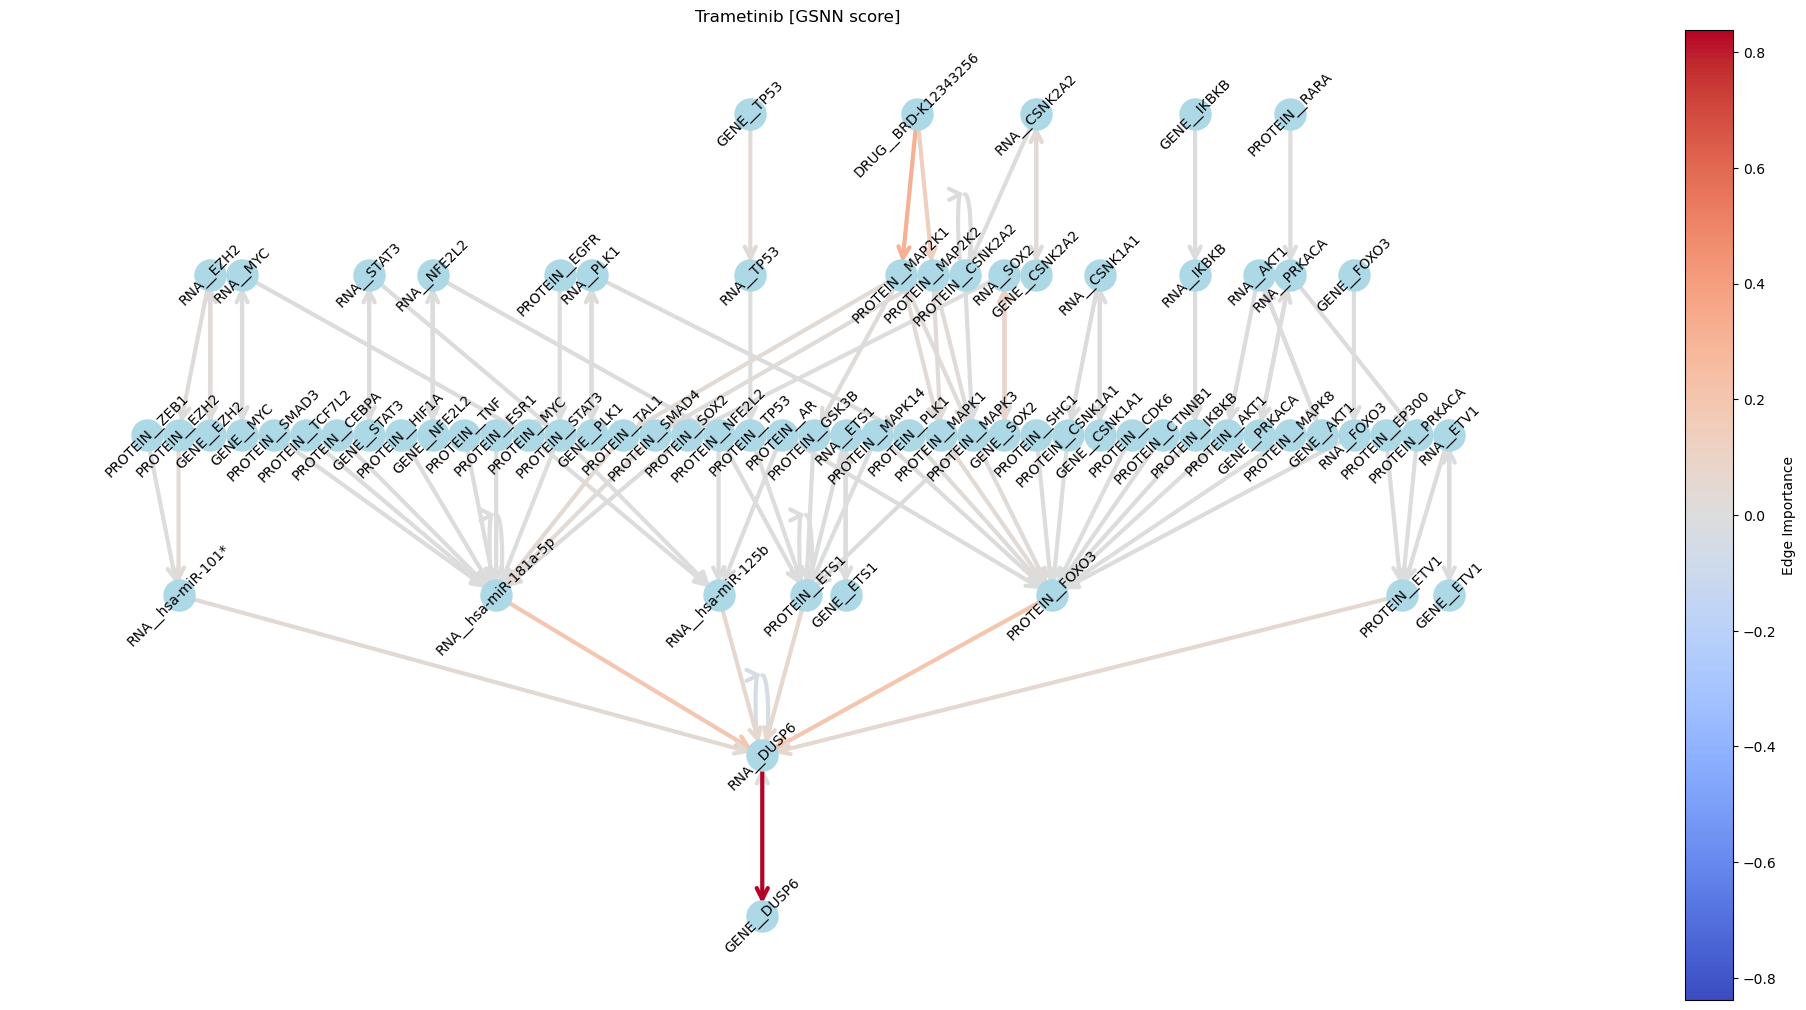

In [14]:
ccres = cres_agg.reset_index().rename(columns={'mean_ig_score': 'score'})
#ccres = ccres.assign(score = lambda x: x.score.values.clip(-0.1,0.1))
ccres = ccres[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))]
ccres = ccres.sort_values(by='mean_gsnn_score', ascending=False)
ccres = ccres[lambda x: x.mean_gsnn_score > 0.5].head(150)

plot_edge_importance(ccres, 
                     figsize=(20,10), 
                     leafs=['GENE__DUSP6'], 
                     title=f'Trametinib [GSNN score]')

In [36]:
foxo3_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('PROTEIN__FOXO3')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('PROTEIN__ETS1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(foxo3_regs) & set(ets1_regs)
overlap


{'LINE__BT20',
 'LINE__BT474',
 'LINE__HME1',
 'LINE__HS578T',
 'LINE__MCF10A',
 'LINE__MCF7',
 'LINE__MDAMB231',
 'LINE__MDAMB468',
 'LINE__SKBR3',
 'LINE__T47D',
 'LINE__ZR751',
 'PROTEIN__MAPK14',
 'PROTEIN__MAPK3'}

In [30]:
mir181_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('hsa-miR-181a-5p')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETS1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(mir181_regs) & set(ets1_regs)
overlap

{'LINE__BT20',
 'LINE__BT474',
 'LINE__HME1',
 'LINE__HS578T',
 'LINE__MCF10A',
 'LINE__MCF7',
 'LINE__MDAMB231',
 'LINE__MDAMB468',
 'LINE__SKBR3',
 'LINE__T47D',
 'LINE__ZR751',
 'PROTEIN__HIF1A',
 'PROTEIN__SMAD4',
 'PROTEIN__TAL1'}

In [31]:
mir181_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('hsa-miR-181a-5p')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
foxo3_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('FOXO3')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(mir181_regs) & set(foxo3_regs)
overlap

{'LINE__BT20',
 'LINE__BT474',
 'LINE__HME1',
 'LINE__HS578T',
 'LINE__MCF10A',
 'LINE__MCF7',
 'LINE__MDAMB231',
 'LINE__MDAMB468',
 'LINE__SKBR3',
 'LINE__T47D',
 'LINE__ZR751',
 'PROTEIN__CEBPA'}

In [34]:
etv1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETV1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets2_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETS2')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(etv1_regs) & set(ets2_regs)
overlap

{'LINE__BT20',
 'LINE__BT474',
 'LINE__HME1',
 'LINE__HS578T',
 'LINE__MCF10A',
 'LINE__MCF7',
 'LINE__MDAMB231',
 'LINE__MDAMB468',
 'LINE__SKBR3',
 'LINE__T47D',
 'LINE__ZR751'}

In [19]:
cres_agg.reset_index().sort_values(by='mean_ig_score', ascending=False).tail(15)[['source', 'target', 'mean_gsnn_score', 'mean_ig_score', 'mean_oc_score']].style.hide()

source,target,mean_gsnn_score,mean_ig_score,mean_oc_score
PROTEIN__MAP2K2,PROTEIN__MAP2K2,0.453702,-0.022113,-0.005927
GENE__CHEK2,RNA__CHEK2,0.836122,-0.024703,-0.032477
LINE__MDAMB231,RNA__CDK2,0.950271,-0.025031,-0.020376
LINE__MDAMB231,RNA__CSNK2A2,0.953756,-0.028338,-0.041157
LINE__MDAMB231,RNA__hsa-miR-101*,0.996938,-0.029246,-0.055987
LINE__MDAMB231,RNA__CEBPA,0.884987,-0.029302,0.009330
GENE__CDK7,RNA__CDK7,0.836175,-0.031577,-0.012520
GENE__HIF1A,RNA__HIF1A,0.742057,-0.034307,-0.016725
LINE__MDAMB231,RNA__hsa-miR-181a-5p,0.998792,-0.040499,-0.040584
PROTEIN__MAP2K1,PROTEIN__MAP2K1,0.692752,-0.042209,-0.015516


# what happens to XX cell line trajectory if we remove X node ? 

In [20]:
def run(root_gsnn, root_traj, sample_id, target_gene, remove_name, cell1, cell2, drug, dose, t=torch.linspace(0, 72, 100)): 

    dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
    obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

    # load data 
    data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
    model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False)
    dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
    x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
    dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

    # freeze the model 
    for param in model.parameters():
        param.requires_grad = False
    
    # set model to evaluation mode 
    model = model.eval() 

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = t.to(device)

    target_ix = data.node_names_dict['output'].index(target_gene)       #

    assert drug in dxdt_meta.pert_id.unique(), f'{drug} not found in dxdt_meta'
    assert cell1 in dxdt_meta.cell_iname.unique(), f'{cell1} not found in dxdt_meta'
    assert cell2 in dxdt_meta.cell_iname.unique(), f'{cell2} not found in dxdt_meta'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                        & (dxdt_meta['cell_iname'] == cell1) 
                        & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

    cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                        & (dxdt_meta['cell_iname'] == cell2) 
                        & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

    dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

    dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

    dataset2 = DXDTDataset(meta=cond2, 
                        input_names=data.node_names_dict['input'], 
                        output_names=data.node_names_dict['output'],
                        src_names=x_names,
                        obs_dir=obs_dir,
                        dxdt_dir=dxdt_dir,
                        scale=dxdt_scale)

    dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)



    def retrieve_data(dataloader):

        xs = []; ys = [] 
        for i, (x, y) in enumerate(dataloader):
            xs.append(x)
            ys.append(y)
        xs = torch.cat(xs, dim=0)
        ys = torch.cat(ys, dim=0)

        return xs, ys 

    x1, y1 = retrieve_data(dataloader1)
    x2, y2 = retrieve_data(dataloader2)

    x0_1 = x1[[0]] # MDAMB231
    x0_2 = x2[[0]] # MCF7

    ode_gsnn = ODEWrapper(model, 
                        data, 
                        dxdt_scale, 
                        t=t, 
                        method= 'euler', 
                        tol=None)

    x1_t_hat = ode_gsnn(x0_1.to(device))
    x2_t_hat = ode_gsnn(x0_2.to(device))

    x1_t_hat_input = x1[0].clone().unsqueeze(0).expand(x1_t_hat.shape[0], -1,).clone()
    x2_t_hat_input = x2[0].clone().unsqueeze(0).expand(x2_t_hat.shape[0], -1,).clone()

    x1_t_hat_input[:, :x1_t_hat.shape[1]] = x1_t_hat
    x2_t_hat_input[:, :x2_t_hat.shape[1]] = x2_t_hat

    edge_mask_ = torch.ones(model.edge_index.shape[1], device=device) 

    src, dst = model.edge_index.detach().cpu()
    remove_ix = model.homo_names.index(remove_name)

    # remove all edges to or from mir181a 
    edge_mask_[src == remove_ix] = 0 
    edge_mask_[dst == remove_ix] = 0 

    #print('# edges removed', edge_mask_.sum() - model.edge_index.shape[1])

    # confirm we removed the right edges 
    homo_names = np.array(model.homo_names) 
    src_name = homo_names[src]
    dst_name = homo_names[dst]

    remove_src = src_name[edge_mask_.cpu() == 0]
    remove_dst = dst_name[edge_mask_.cpu() == 0]

    assert all([(a == remove_name) or (b == remove_name) for a, b in zip(remove_src, remove_dst)]), 'we removed the wrong edges'

    # generate trajectories with edge mask 
    x1_t_hat_nm = ode_gsnn(x0_1.to(device), edge_mask=edge_mask_)
    x2_t_hat_nm = ode_gsnn(x0_2.to(device), edge_mask=edge_mask_)

    return x1_t_hat[:, target_ix], x2_t_hat[:, target_ix], x1_t_hat_nm[:, target_ix], x2_t_hat_nm[:, target_ix]
    


In [21]:
root_gsnn = root 
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/default_v03_from_arc'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

# FOS: Classic ERK-induced IEG, part of the AP-1 transcription factor.
# EGR1: Rapid early response gene downstream of ERK.
# JUN: Partner in AP-1, ERK-responsive.
# DUSP4, DUSP6: Like DUSP6, negative feedback regulators of ERK.

drug = 'BRD-K12343256' # trametinib (MEK)
dose = 10.0

cell1 = 'MDAMB231' #'BT20'  #RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20, which have hyperactive MAPK signaling and are very sensitive to MEK inhibition
cell2 = 'MCF7' #'T47D' #'MCF7' # PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition

#remove_name = 'PROTEIN__ETV1'
#remove_name = 'PROTEIN__ETS1'
#remove_name = 'PROTEIN__FOXO3'
remove_name = 'RNA__hsa-miR-181a-5p'
#remove_name = 'RNA__hsa-miR-125b-5p'

target_gene = 'GENE__DUSP6' #'GENE__CCND1' # # 

t = torch.linspace(0, 72, 100)

In [22]:
res_masked = {}
for sample_ix in range(50):
    print(f'sample {sample_ix}', end='\r')
    sample_id = f'sample_{sample_ix}'
    x1_t_hat, x2_t_hat, x1_t_hat_nm, x2_t_hat_nm = run(root_gsnn, root_traj, sample_id, target_gene, remove_name, cell1, cell2, drug, dose, t=t)
    res_masked[sample_id] = {f'{cell1}_masked_{remove_name}': x1_t_hat_nm, 
                            f'{cell2}_masked_{remove_name}': x2_t_hat_nm, 
                            f'{cell1}_all': x1_t_hat, 
                            f'{cell2}_all': x2_t_hat}

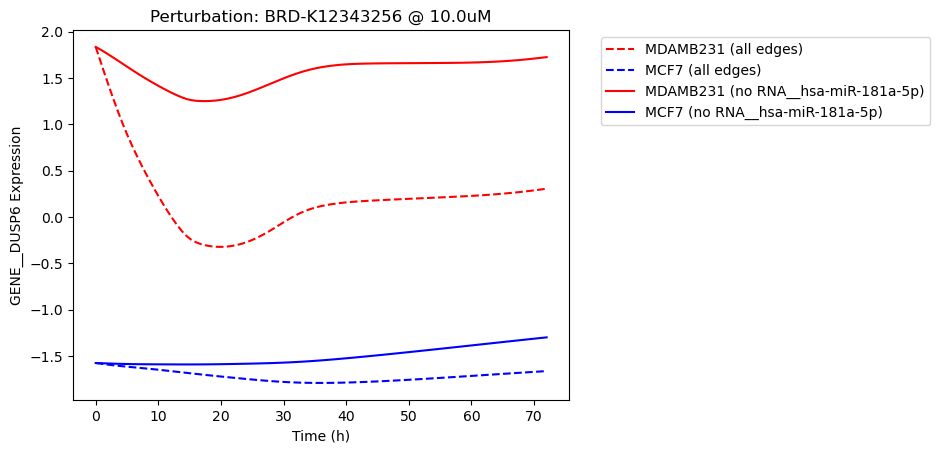

In [23]:
plt.figure()

diffs1 = [] 
diffs2 = [] 
for i, sample_id in enumerate(res_masked):
    x1_t_hat, x2_t_hat = res_masked[sample_id][f'{cell1}_all'], res_masked[sample_id][f'{cell2}_all']
    x1_t_hat_nm, x2_t_hat_nm = res_masked[sample_id][f'{cell1}_masked_{remove_name}'], res_masked[sample_id][f'{cell2}_masked_{remove_name}']
    
    diffs1.append(x1_t_hat_nm - x1_t_hat) 
    diffs2.append(x2_t_hat_nm - x2_t_hat) 

    if i == 0:
        plt.plot(np.linspace(0,t.max().item(), x1_t_hat.shape[0]), x1_t_hat.detach().cpu().numpy(), 'r--', label=f'{cell1} (all edges)')
        plt.plot(np.linspace(0,t.max().item(), x2_t_hat.shape[0]), x2_t_hat.detach().cpu().numpy(), 'b--', label=f'{cell2} (all edges)')
        plt.plot(np.linspace(0,t.max().item(), x1_t_hat_nm.shape[0]), x1_t_hat_nm.detach().cpu().numpy(), 'r-', label=f'{cell1} (no {remove_name})')
        plt.plot(np.linspace(0,t.max().item(), x2_t_hat_nm.shape[0]), x2_t_hat_nm.detach().cpu().numpy(), 'b-', label=f'{cell2} (no {remove_name})')
    else: 
        plt.plot(np.linspace(0,t.max().item(), x1_t_hat.shape[0]), x1_t_hat.detach().cpu().numpy(), 'r--')
        plt.plot(np.linspace(0,t.max().item(), x2_t_hat.shape[0]), x2_t_hat.detach().cpu().numpy(), 'b--')
        plt.plot(np.linspace(0,t.max().item(), x1_t_hat_nm.shape[0]), x1_t_hat_nm.detach().cpu().numpy(), 'r-')
        plt.plot(np.linspace(0,t.max().item(), x2_t_hat_nm.shape[0]), x2_t_hat_nm.detach().cpu().numpy(), 'b-')

    break 

plt.title(f'Perturbation: {drug} @ {dose}uM')
plt.xlabel('Time (h)')
plt.ylabel(f'{target_gene} Expression')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

diffs1 = torch.stack(diffs1, dim=0) 
diffs2 = torch.stack(diffs2, dim=0) 


<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10136/664658452.py:11: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel(f'$\Delta$ {target_gene.split("__")[1]}')


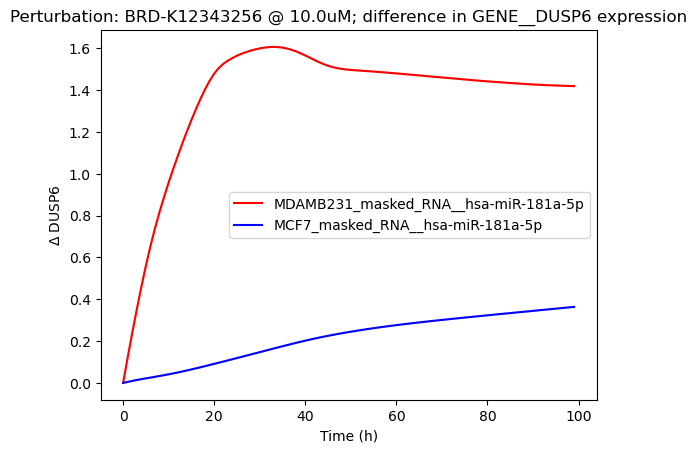

In [24]:

plt.figure() 
plt.title(f'Perturbation: {drug} @ {dose}uM; difference in {target_gene} expression')
plt.plot(diffs1.mean(dim=0).detach().cpu().numpy(), 'r-', label=f'{cell1}_masked_{remove_name}')
plt.plot(diffs2.mean(dim=0).detach().cpu().numpy(), 'b-', label=f'{cell2}_masked_{remove_name}')

for i in range(diffs1.shape[0]):
    plt.plot(diffs1[i, :].detach().cpu().numpy(), 'r-', alpha=0.1)
    plt.plot(diffs2[i, :].detach().cpu().numpy(), 'b-', alpha=0.1)

plt.xlabel('Time (h)')
plt.ylabel(f'$\Delta$ {target_gene.split("__")[1]}')
plt.legend() 
plt.show() 

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2951/712277993.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel(f'P($\Delta$ {target_gene.split("__")[1]} > 0)')


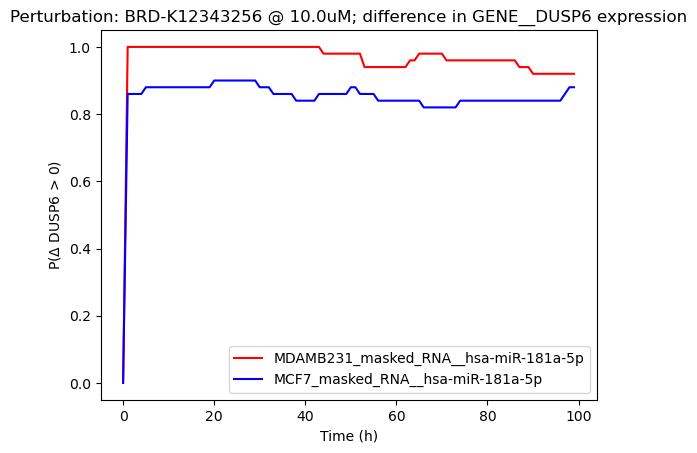

In [319]:
plt.figure() 
plt.title(f'Perturbation: {drug} @ {dose}uM; difference in {target_gene} expression')
plt.plot((diffs1 > 0).float().mean(dim=0).detach().cpu().numpy(), 'r-', label=f'{cell1}_masked_{remove_name}')
plt.plot((diffs2 > 0).float().mean(dim=0).detach().cpu().numpy(), 'b-', label=f'{cell2}_masked_{remove_name}')

plt.xlabel('Time (h)')
plt.ylabel(f'P($\Delta$ {target_gene.split("__")[1]} > 0)')
plt.legend() 
plt.show() 

In [280]:
diffs1.shape

torch.Size([300])

# Number of paths in subgraph 

1. Count the total number of paths from drug targets -> target gene 
2. Count the number of paths from drug targets -> target gene that are contained within the subgraph 
3. report the fraction of paths in subgraph explanation 


In [321]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)

In [322]:
src1,dst1 = data.edge_index_dict['function', 'to', 'function']
src2,dst2 = data.edge_index_dict['input', 'to', 'function']
src3,dst3 = data.edge_index_dict['function', 'to', 'output']

all_edges1 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src1], 'target': np.array(data.node_names_dict['function'])[dst1]})
all_edges2 = pd.DataFrame({'source': np.array(data.node_names_dict['input'])[src2], 'target': np.array(data.node_names_dict['function'])[dst2]})
all_edges3 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src3], 'target': np.array(data.node_names_dict['output'])[dst3]})

all_edges = pd.concat([all_edges1, all_edges2, all_edges3])
G_full = nx.from_pandas_edgelist(all_edges, source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_full))
print('# edges', len(G_full.edges()))


# nodes 3299
# edges 41339


In [323]:
G_subgraph = nx.from_pandas_edgelist(cres_agg.reset_index()[lambda x: x.prob_gsnn_score > 0.5], source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_subgraph))
print('# edges', len(G_subgraph.edges()))


# nodes 392
# edges 795


In [324]:
root_genes = 'DRUG__BRD-K12343256'
leaf_genes = 'GENE__DUSP6'
depth = 6

In [325]:
all_paths = list(nx.all_simple_edge_paths(G_full, source=root_genes, target=leaf_genes, cutoff=depth))
print('# all paths', len(all_paths))
subgraph_paths = list(nx.all_simple_edge_paths(G_subgraph, source=root_genes, target=leaf_genes, cutoff=depth))
print('# subgraph paths', len(subgraph_paths))

# all paths 198
# subgraph paths 79


In [326]:
print(f'Fraction of paths in subgraph -> {len(subgraph_paths) / len(all_paths):.2f} [{len(subgraph_paths)} / {len(all_paths)}]')
print() 

print('Fraction of edges in subgraph (by length): ') 

path_lengths_subgraph = [len(p) for p in subgraph_paths] 
path_lengths_full = [len(p) for p in all_paths] 

for i in range(4, depth+1):
    n_paths_subgraph = np.sum([p == i for p in path_lengths_subgraph])
    n_paths_full = np.sum([p == i for p in path_lengths_full])
    print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


Fraction of paths in subgraph -> 0.40 [79 / 198]

Fraction of edges in subgraph (by length): 
	Fraction of paths of length 4 -> nan [0 / 0]
	Fraction of paths of length 5 -> 1.00 [9 / 9]
	Fraction of paths of length 6 -> 0.37 [70 / 189]


/tmp/ipykernel_2951/3546800955.py:12: RuntimeWarning: invalid value encountered in scalar divide
  print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


In [327]:
cres_agg.head() 

mean_gsnn_score  std_gsnn_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.998185        0.006857   
                    PROTEIN__MAP2K2         0.989901        0.024313   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.025500        0.007484   
                    PROTEIN__ERBB2          0.025055        0.006997   
                    PROTEIN__ERBB4          0.026630        0.007858   

                                     prob_gsnn_score  mean_ig_score  \
source              target                                            
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.980769       0.320484   
                    PROTEIN__MAP2K2         0.980769       0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.000000       0.000000   
                    PROTEIN__ERBB2          0.000000       0.000000   
                    PROTEIN__ERBB4          0.000000       0.000000   

                                     std_ig_score  prob_pos_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.216513                1.0   
                    PROTEIN__MAP2K2      0.144622                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_ig_score  mean_oc_score  \
source              target                                              
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0       1.556895   
                    PROTEIN__MAP2K2                0.0       0.608180   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0       0.000000   
                    PROTEIN__ERBB2                 0.0       0.000000   
                    PROTEIN__ERBB4                 0.0       0.000000   

                                     std_oc_score  prob_pos_oc_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.713094                1.0   
                    PROTEIN__MAP2K2      0.508077                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_oc_score  abs_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0      0.320484   
                    PROTEIN__MAP2K2                0.0      0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0      0.000000   
                    PROTEIN__ERBB2                 0.0      0.000000   
                    PROTEIN__ERBB4                 0.0      0.000000   

                                     abs_oc_score  
source              target                         
DRUG__BRD-K12343256 PROTEIN__MAP2K1      1.556895  
                    PROTEIN__MAP2K2      0.608180  
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000  
                    PROTEIN__ERBB2       0.000000  
                    PROTEIN__ERBB4       0.000000

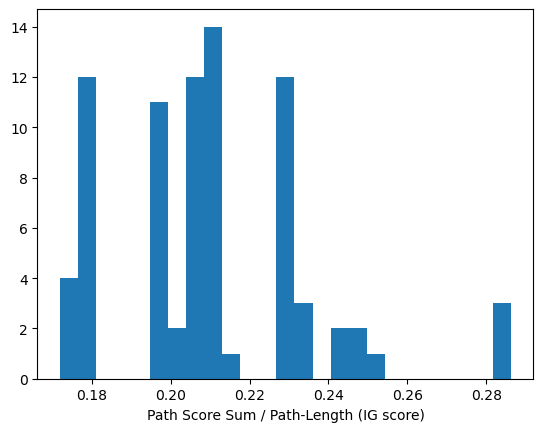

Highest scoring path: 0.29
Path edges: [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'), ('PROTEIN__MAP2K1', 'PROTEIN__TAL1'), ('PROTEIN__TAL1', 'RNA__hsa-miR-181a-5p'), ('RNA__hsa-miR-181a-5p', 'RNA__DUSP6'), ('RNA__DUSP6', 'GENE__DUSP6')]
Lowest scoring path: 0.17
Path edges: [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K2'), ('PROTEIN__MAP2K2', 'PROTEIN__FOS'), ('PROTEIN__FOS', 'RNA__ETS1'), ('RNA__ETS1', 'PROTEIN__ETS1'), ('PROTEIN__ETS1', 'RNA__DUSP6'), ('RNA__DUSP6', 'GENE__DUSP6')]


In [328]:
def sum_path_scores(path, edge_scores, score_name='mean_ig_score'): 

    return (np.sum([edge_scores.loc[e][score_name] for e in path]) / len(path)).item()

gsnn_path_scores = [sum_path_scores(subgraph_paths[i], cres_agg) for i in range(len(subgraph_paths))]

plt.figure() 
plt.hist(gsnn_path_scores, bins=25, label='subgraph')
plt.xlabel('Path Score Sum / Path-Length (IG score)')
plt.show() 

top5_highest_scoring_paths = np.argsort(gsnn_path_scores)[-5:][::-1]
top5_highest_scoring_path_scores = np.array(gsnn_path_scores)[top5_highest_scoring_paths]
top5_highest_scoring_path_edges = [subgraph_paths[i] for i in top5_highest_scoring_paths]


print(f'Highest scoring path: {top5_highest_scoring_path_scores[0]:.2f}')
print(f'Path edges: {top5_highest_scoring_path_edges[0]}')

top5_lowest_scoring_paths = np.argsort(gsnn_path_scores)[:5]
top5_lowest_scoring_path_scores = np.array(gsnn_path_scores)[top5_lowest_scoring_paths]
top5_lowest_scoring_path_edges = [subgraph_paths[i] for i in top5_lowest_scoring_paths]

print(f'Lowest scoring path: {top5_lowest_scoring_path_scores[0]:.2f}')
print(f'Path edges: {top5_lowest_scoring_path_edges[0]}')


In [329]:
top5_highest_scoring_path_edges

[[('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'),
  ('PROTEIN__MAP2K1', 'PROTEIN__TAL1'),
  ('PROTEIN__TAL1', 'RNA__hsa-miR-181a-5p'),
  ('RNA__hsa-miR-181a-5p', 'RNA__DUSP6'),
  ('RNA__DUSP6', 'GENE__DUSP6')],
 [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'),
  ('PROTEIN__MAP2K1', 'PROTEIN__MAPK1'),
  ('PROTEIN__MAPK1', 'PROTEIN__FOXO3'),
  ('PROTEIN__FOXO3', 'RNA__DUSP6'),
  ('RNA__DUSP6', 'GENE__DUSP6')],
 [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'),
  ('PROTEIN__MAP2K1', 'PROTEIN__MAPK3'),
  ('PROTEIN__MAPK3', 'PROTEIN__FOXO3'),
  ('PROTEIN__FOXO3', 'RNA__DUSP6'),
  ('RNA__DUSP6', 'GENE__DUSP6')],
 [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'),
  ('PROTEIN__MAP2K1', 'PROTEIN__MAPK3'),
  ('PROTEIN__MAPK3', 'PROTEIN__ETS1'),
  ('PROTEIN__ETS1', 'RNA__DUSP6'),
  ('RNA__DUSP6', 'GENE__DUSP6')],
 [('DRUG__BRD-K12343256', 'PROTEIN__MAP2K1'),
  ('PROTEIN__MAP2K1', 'PROTEIN__GSK3B'),
  ('PROTEIN__GSK3B', 'PROTEIN__ETS1'),
  ('PROTEIN__ETS1', 'RNA__DUSP6'),
  ('RNA__DUSP6', 'GENE__DUSP6')]]

# Centrality of miRNAs 

In [330]:
full_centrality = nx.betweenness_centrality(G_full) 

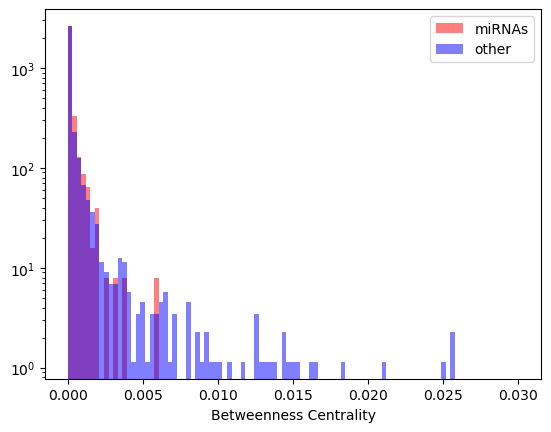

In [331]:

mirna_centralities = {k: v for k, v in full_centrality.items() if k.startswith('RNA__hsa-miR-')}
other_centralities = {k: v for k, v in full_centrality.items() if not k.startswith('RNA__hsa-miR-')}

binss = np.linspace(0,0.03, 100)

plt.figure() 
plt.hist(list(mirna_centralities.values()), bins=binss, label='miRNAs', color='r', alpha=0.5, density=True)
plt.hist(list(other_centralities.values()), bins=binss, label='other', color='b', alpha=0.5, density=True)
plt.yscale('log')
plt.legend()
plt.xlabel('Betweenness Centrality')
plt.show() 

# CELL1 explanation

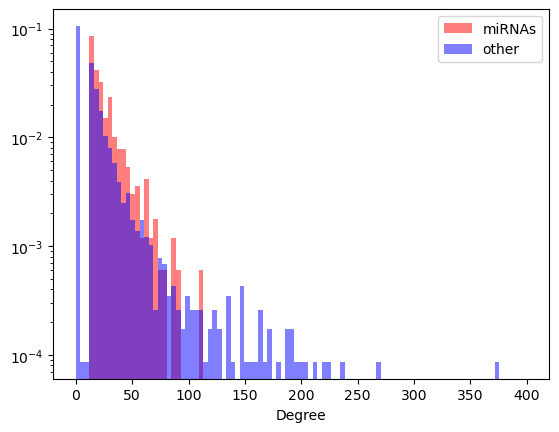

In [333]:
full_degrees = dict(G_full.degree()) 

mirna_degrees = {k: v for k, v in full_degrees.items() if k.startswith('RNA__hsa-miR-')}
other_degrees = {k: v for k, v in full_degrees.items() if not k.startswith('RNA__hsa-miR-')}

binss = np.linspace(0, 400, 100)

plt.figure() 
plt.hist(list(mirna_degrees.values()), bins=binss, label='miRNAs', color='r', alpha=0.5, density=True)
plt.hist(list(other_degrees.values()), bins=binss, label='other', color='b', alpha=0.5, density=True)
plt.yscale('log')
plt.legend()
plt.xlabel('Degree')
plt.show() 


# GSEA 

In [334]:
cres_agg.head() 

mean_gsnn_score  std_gsnn_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.998185        0.006857   
                    PROTEIN__MAP2K2         0.989901        0.024313   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.025500        0.007484   
                    PROTEIN__ERBB2          0.025055        0.006997   
                    PROTEIN__ERBB4          0.026630        0.007858   

                                     prob_gsnn_score  mean_ig_score  \
source              target                                            
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.980769       0.320484   
                    PROTEIN__MAP2K2         0.980769       0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR           0.000000       0.000000   
                    PROTEIN__ERBB2          0.000000       0.000000   
                    PROTEIN__ERBB4          0.000000       0.000000   

                                     std_ig_score  prob_pos_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.216513                1.0   
                    PROTEIN__MAP2K2      0.144622                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_ig_score  mean_oc_score  \
source              target                                              
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0       1.556895   
                    PROTEIN__MAP2K2                0.0       0.608180   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0       0.000000   
                    PROTEIN__ERBB2                 0.0       0.000000   
                    PROTEIN__ERBB4                 0.0       0.000000   

                                     std_oc_score  prob_pos_oc_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.713094                1.0   
                    PROTEIN__MAP2K2      0.508077                1.0   
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000                0.0   
                    PROTEIN__ERBB2       0.000000                0.0   
                    PROTEIN__ERBB4       0.000000                0.0   

                                     prob_neg_oc_score  abs_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1                0.0      0.320484   
                    PROTEIN__MAP2K2                0.0      0.135782   
DRUG__BRD-K19687926 PROTEIN__EGFR                  0.0      0.000000   
                    PROTEIN__ERBB2                 0.0      0.000000   
                    PROTEIN__ERBB4                 0.0      0.000000   

                                     abs_oc_score  
source              target                         
DRUG__BRD-K12343256 PROTEIN__MAP2K1      1.556895  
                    PROTEIN__MAP2K2      0.608180  
DRUG__BRD-K19687926 PROTEIN__EGFR        0.000000  
                    PROTEIN__ERBB2       0.000000  
                    PROTEIN__ERBB4       0.000000

In [335]:
G = nx.from_pandas_edgelist(cres_agg[lambda x: x.prob_gsnn_score > 0.5].reset_index(), source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr2 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr2.res2d.sort_values(by='Adjusted P-value', ascending=True).head(40)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Generic Transcription Pathway R-HSA-212436,2.547012e-19
1,RNA Polymerase II Transcription R-HSA-73857,3.922506e-18
2,Gene Expression (Transcription) R-HSA-74160,1.233963e-17
3,Signal Transduction R-HSA-162582,8.988960e-16
4,Developmental Biology R-HSA-1266738,2.570912e-13
5,Disease R-HSA-1643685,2.422400e-12
6,Signaling By Interleukins R-HSA-449147,4.728766e-12
7,Cytokine Signaling In Immune System R-HSA-1280215,8.969287e-12
9,Cellular Senescence R-HSA-2559583,3.163546e-11
8,MyD88:MAL(TIRAP) Cascade Initiated On Plasma M...,3.163546e-11
